# Tempest: FWI Predictor
## Milestones Covered
- **Milestone 1 (Week 1-2):** Module 1 (Data Collection), Module 2 (EDA + Preprocessing)
- **Milestone 2 (Week 3-4):** Module 3 (Feature Engineering + Scaling), Module 4 (Ridge Model Training)
- **Milestone 3 (Week 5-6):** Module 5 (Evaluation + Optimization)
- **Milestone 4 (Week 7-8):** Module 6 (Flask Scaffolding), Module 7 (Presentation + Documentation)

In [4]:
from pathlib import Path
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "Algerian_forest_fires_dataset_UPDATE.csv"
MODELS_DIR = ROOT / "models"
ARTIFACTS_DIR = ROOT / "artifacts"
TEMPLATES_DIR = ROOT / "templates"

MODELS_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR.mkdir(exist_ok=True)
TEMPLATES_DIR.mkdir(exist_ok=True)

print("Data file:", DATA_PATH)
print("Models folder:", MODELS_DIR)
print("Artifacts folder:", ARTIFACTS_DIR)

Data file: /Users/aryamannain/InfosysVirtualIntern/FWI_Predictor/data/Algerian_forest_fires_dataset_UPDATE.csv
Models folder: /Users/aryamannain/InfosysVirtualIntern/FWI_Predictor/models
Artifacts folder: /Users/aryamannain/InfosysVirtualIntern/FWI_Predictor/artifacts


## Milestone 1 — Module 1: Data Collection

- Load the Algerian FWI dataset from workspace
- Handle raw formatting quirks (region header lines, spacing, mixed formatting)
- Validate data types and consistency
- Build a clean DataFrame ready for EDA

In [5]:
# Read raw lines and keep only valid data rows
lines = DATA_PATH.read_text(encoding="utf-8", errors="ignore").splitlines()

rows = []
region = None
for line in lines:
    text = line.strip()
    if not text:
        continue

    if "Region Dataset" in text:
        region = text.replace("Region Dataset", "").strip()
        continue

    if text.lower().startswith("day,month,year"):
        continue

    parts = [p.strip() for p in text.split(",")]
    if len(parts) < 14:
        continue

    # Keep only rows where day/month/year are numbers
    if not (parts[0].isdigit() and parts[1].isdigit() and parts[2].isdigit()):
        continue

    rows.append(parts[:14] + [region])

columns = [
    "day", "month", "year", "Temperature", "RH", "Ws", "Rain",
    "FFMC", "DMC", "DC", "ISI", "BUI", "FWI", "Classes", "Region"
]
df = pd.DataFrame(rows, columns=columns)

# Convert numeric columns
numeric_cols = ["Temperature", "RH", "Ws", "Rain", "FFMC", "DMC", "DC", "ISI", "BUI", "FWI"]
for c in ["day", "month", "year"] + numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Clean text columns
df["Classes"] = df["Classes"].astype(str).str.strip().str.lower()
df["Region"] = df["Region"].astype(str).str.strip()

# Basic cleanup
df = df.dropna(subset=["day", "month", "year", "FWI"]).drop_duplicates().reset_index(drop=True)

print("Shape:", df.shape)
print(df[["Region", "Classes"]].head())
df.head()

Shape: (243, 15)
   Region   Classes
0  Bejaia  not fire
1  Bejaia  not fire
2  Bejaia  not fire
3  Bejaia  not fire
4  Bejaia  not fire


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,Bejaia
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,Bejaia
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,Bejaia
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,Bejaia
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,Bejaia


## Milestone 1 — Module 2: Data Exploration and Data Preprocessing

- Missing value check and handling
- Outlier detection with boxplots and IQR thresholds
- Distribution plots and correlation analysis
- Encoding categorical columns
- Save cleaned dataset

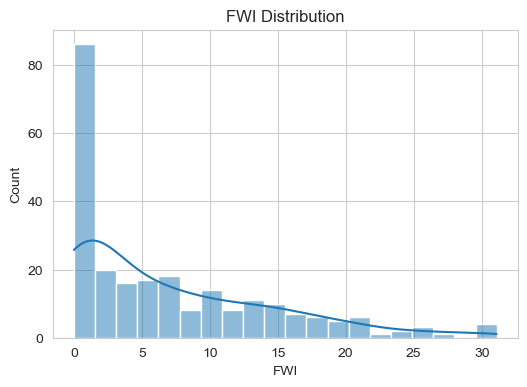

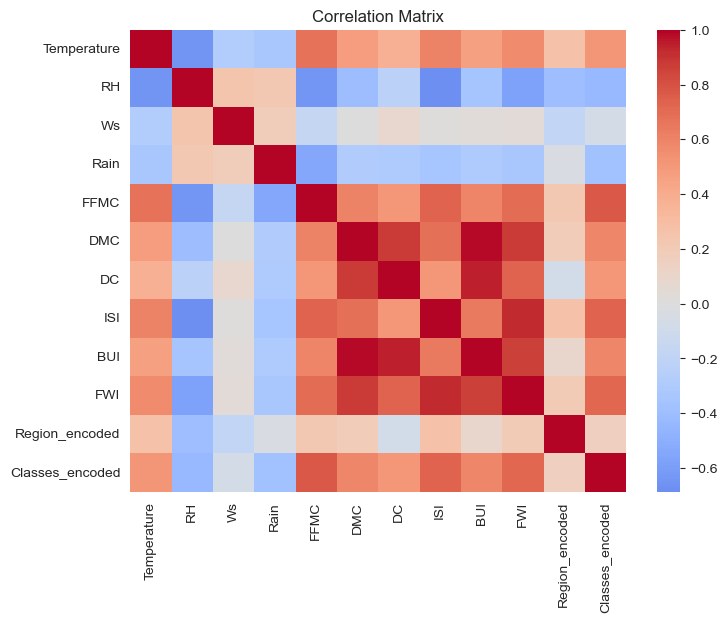

Saved: /Users/aryamannain/InfosysVirtualIntern/FWI_Predictor/artifacts/cleaned_fwi_dataset.csv


In [6]:
# Fill missing values (simple strategy)
for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

if df["Classes"].isna().any():
    df["Classes"] = df["Classes"].fillna("not fire")
if df["Region"].isna().any():
    df["Region"] = df["Region"].fillna(df["Region"].mode()[0])

# Encode categories
df["Classes_encoded"] = df["Classes"].map({"not fire": 0, "fire": 1}).fillna(0).astype(int)
region_map = {name: idx for idx, name in enumerate(sorted(df["Region"].unique()))}
df["Region_encoded"] = df["Region"].map(region_map).astype(int)

# Quick EDA plots
plt.figure(figsize=(6, 4))
sns.histplot(df["FWI"], bins=20, kde=True)
plt.title("FWI Distribution")
plt.show()

plt.figure(figsize=(8, 6))
corr_cols = numeric_cols + ["Region_encoded", "Classes_encoded"]
sns.heatmap(df[corr_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

cleaned_path = ARTIFACTS_DIR / "cleaned_fwi_dataset.csv"
df.to_csv(cleaned_path, index=False)
print("Saved:", cleaned_path)

## Milestone 2 — Module 3: Feature Engineering and Scaling

- Select key features by correlation with FWI
- Split into X and y
- Train-test split
- Fit StandardScaler and save as `models/scaler.pkl`
- Save feature list for deployment

In [7]:
# Choose a simple fixed set of useful features
selected_features = [
    "Temperature", "RH", "Ws", "Rain", "FFMC", "DMC", "ISI", "BUI", "Region_encoded"
]

X = df[selected_features].copy()
y = df["FWI"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

with open(MODELS_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

(MODELS_DIR / "features.json").write_text(
    json.dumps(selected_features, indent=2), encoding="utf-8"
)

print("Selected features:", selected_features)
print("Saved scaler and features file")

Selected features: ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'ISI', 'BUI', 'Region_encoded']
Saved scaler and features file


## Milestone 2 — Module 4: Model Training using Ridge Regression

- Tune alpha for bias-variance tradeoff
- Train using cross-validation
- Evaluate train/test performance
- Save model as `models/ridge.pkl`

In [8]:
# Train a simple Ridge model
model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

with open(MODELS_DIR / "ridge.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model trained and saved to models/ridge.pkl")

Model trained and saved to models/ridge.pkl


## Milestone 3 — Module 5: Evaluation and Optimization

- Report MAE, RMSE, and R²
- Plot actual vs predicted and residuals
- Capture optimization notes

,split,MAE,RMSE,R2
0,train,0.683584,1.273421,0.973272
1,test,0.473268,0.672958,0.985058


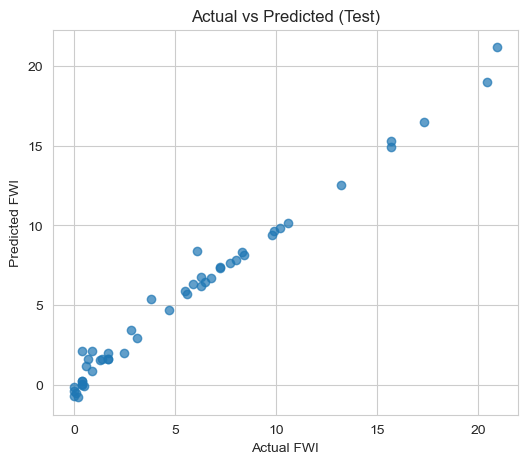

Saved: /Users/aryamannain/InfosysVirtualIntern/FWI_Predictor/artifacts/model_metrics.csv


In [9]:
# Simple evaluation
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

metrics_df = pd.DataFrame(
    [
        {"split": "train", "MAE": train_mae, "RMSE": train_rmse, "R2": train_r2},
        {"split": "test", "MAE": test_mae, "RMSE": test_rmse, "R2": test_r2},
    ]
)
display(metrics_df)

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted (Test)")
plt.show()

metrics_path = ARTIFACTS_DIR / "model_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
print("Saved:", metrics_path)

## Milestone 4 — Module 6: Deployment via Flask App

This cell generates:
- `app.py`
- `templates/index.html`
- `templates/home.html`

The app loads `models/ridge.pkl`, `models/scaler.pkl`, and `models/features.json` for inference.

In [10]:
# Create a simple Flask app file and templates
app_py = '''from pathlib import Path
import json
import pickle
import pandas as pd
from flask import Flask, render_template, request

ROOT = Path(__file__).resolve().parent
MODELS = ROOT / "models"

with open(MODELS / "ridge.pkl", "rb") as f:
    model = pickle.load(f)
with open(MODELS / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
features = json.loads((MODELS / "features.json").read_text(encoding="utf-8"))

app = Flask(__name__)

@app.route("/")
def index():
    return render_template("index.html", features=features)

@app.route("/predict", methods=["POST"])
def predict():
    values = [float(request.form.get(f, 0)) for f in features]
    input_df = pd.DataFrame([values], columns=features)
    pred = model.predict(scaler.transform(input_df))[0]
    return render_template("home.html", prediction=round(float(pred), 3))

if __name__ == "__main__":
    app.run(debug=True)
'''

index_html = '''<!doctype html>
<html><head><meta charset="utf-8"><title>FWI Predictor</title></head>
<body>
  <h1>FWI Predictor</h1>
  <form action="/predict" method="post">
    {% for feature in features %}
      <label>{{ feature }}:</label>
      <input type="number" step="any" name="{{ feature }}" required><br><br>
    {% endfor %}
    <button type="submit">Predict</button>
  </form>
</body></html>
'''

home_html = '''<!doctype html>
<html><head><meta charset="utf-8"><title>Result</title></head>
<body>
  <h1>Predicted FWI</h1>
  <h2>{{ prediction }}</h2>
  <a href="/">Back</a>
</body></html>
'''

(ROOT / "app.py").write_text(app_py, encoding="utf-8")
(TEMPLATES_DIR / "index.html").write_text(index_html, encoding="utf-8")
(TEMPLATES_DIR / "home.html").write_text(home_html, encoding="utf-8")

print("Simple Flask files generated")

Simple Flask files generated


## Milestone 4 — Module 7: Presentation and Documentation

### Project Summary
This project predicts the **Fire Weather Index (FWI)** from environmental and weather-related features using **Ridge Regression**.

### End-to-End Workflow
```mermaid
flowchart LR
    A[Raw Algerian Dataset] --> B[Parsing + Cleaning]
    B --> C[EDA + Correlation + Encoding]
    C --> D[Feature Selection]
    D --> E[Train/Test Split]
    E --> F[StandardScaler Fit]
    F --> G[Ridge Regression + Alpha Tuning]
    G --> H[Evaluation: MAE RMSE R2]
    G --> I[Save Artifacts: ridge.pkl scaler.pkl features.json]
    I --> J[Flask App Inference]
```

### Deliverables Checklist
- [x] Cleaned dataset (`artifacts/cleaned_fwi_dataset.csv`)
- [x] Trained model (`models/ridge.pkl`)
- [x] Scaler (`models/scaler.pkl`)
- [x] Feature list (`models/features.json`)
- [x] Evaluation report (`artifacts/model_metrics.csv`)
- [x] Flask app scaffold (`app.py`, `templates/index.html`, `templates/home.html`)